# CTM-UNet — Tsetlin machines for semantic segmentation

> **Paper.** Yi Liu, K. Darshana Abeyrathna, *CTM-UNet: Integrating Convolutional Tsetlin
> Machines with U-Net Architecture for Semantic Segmentation*, ISTM 2025.
> [doi:10.1109/ISTM67926.2025.00013](https://doi.org/10.1109/ISTM67926.2025.00013) ·
> code: [github.com/yiliu-coding/CTM-UNet](https://github.com/yiliu-coding/CTM-UNet)
> (PDF in `source_documents/papers/03_segmentation/`)

This is, as far as the repository's literature survey could establish, **the only paper that
puts a Tsetlin machine into a segmentation architecture**. A title/abstract search over a
422-paper arXiv TM corpus for `segmentation`, `unet`, `mask`, `pixel-wise` and `delineat`
returns no other match. So this notebook is less "here is a well-trodden technique" and more
"here is the entire state of the art, and here is what is actually load-bearing in it".

**What CTM-UNet does.** U-Net's convolution blocks are replaced by CTM blocks —
`Conv2D → binarise → CTM2D → integer votes → cast to float` — so ordinary float tensors still
flow between levels and the encoder/decoder/skip structure is untouched. RGB is booleanised as
8 place-value bits per channel (`H×W×3 → H×W×24`). The head is `K` parallel CTMs, one per
class; votes are scaled to logits and softmaxed, and feedback is per-pixel one-vs-rest
Type I / Type II. Trained on CamVid at 512×512 with `T = 50`, 3×3 patches and clauses ≈ 4×
channels.

**What this notebook does.** `torchtsetlin` has no U-Net, and it has no dense CTM either — so
we build one, and use it to test which of the paper's ingredients actually carry the result:

1. show concretely **why a stock convolutional TM cannot segment at all**;
2. build a **dense (per-pixel) TM head** — the paper's "K parallel CTM heads" — in ~15 lines;
3. train it on CamVid-like synthetic street scenes and report per-class IoU and mIoU;
4. reproduce the paper's **sky-vs-rest** experiment *together with the baselines the paper
   does not report*, which is necessary to read its headline number correctly;
5. test the **`Conv2D` front-end that never receives a gradient** — a consequence of the
   paper's own statement that the loss is monitored, not trained through;
6. add multi-scale context two ways (the paper's stagewise dataflow, and a patch pyramid) and
   measure what U-Net's actual contribution is worth here;
7. redo the **memory arithmetic** of Tables III/IV and reconcile it with the conclusion.

Runtime: ~8 minutes on a GPU.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchtsetlin as tt

SEED = 0
tt.seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torchtsetlin", tt.__version__, "| torch", torch.__version__, "| device", device)

SKY, BUILDING, TREE, ROAD = 0, 1, 2, 3
CLASSES = ["sky", "building", "tree", "road"]
PALETTE = np.array([[0.45, 0.62, 0.86], [0.62, 0.58, 0.53], [0.25, 0.50, 0.26], [0.38, 0.38, 0.40]])

torchtsetlin 0.1.1 | torch 2.10.0+cu128 | device cuda


## 1. Why a stock convolutional TM cannot segment

This is the obstacle the paper exists to get around, and it is worth seeing rather than
assuming. In a convolutional TM a clause is a filter that slides over the image, and the
clause's output for the *image* is the **disjunction over all patch positions** (Granmo et al.
2019, and the C-RTM paper's Eq. 4):

$$c_j \;=\; \bigvee_{b=1}^{B} c_j^{\,b}$$

The clause fires if it matched *somewhere*. That OR is exactly what makes a CTM a good
classifier — it gives translation tolerance — and exactly what destroys a segmentation output,
because after it there is no longer any "where" left to report.

In [2]:
demo = tt.ConvTsetlinMachine(
    n_classes=4, n_clauses=20, T=20, s=10.0, patch_size=3,
    input_shape=(12, 32, 32), position_encoding=True,
).to(device)
demo.eval()
dummy = (torch.rand(4, 12, 32, 32, device=device) < 0.5).float()

print("input  :", tuple(dummy.shape), " (4 images, 12 bit-planes, 32x32 pixels)")
print("output :", tuple(demo(dummy).shape), " <- one vote vector per IMAGE")
print("\n1024 pixels in, 4 numbers out. There is no per-pixel prediction to be had:")
print("the clause outputs were OR-ed across all", demo._patches_per_example(dummy),
      "patch positions before voting.")

input  : (4, 12, 32, 32)  (4 images, 12 bit-planes, 32x32 pixels)


output : (4, 4)  <- one vote vector per IMAGE

1024 pixels in, 4 numbers out. There is no per-pixel prediction to be had:
the clause outputs were OR-ed across all 900 patch positions before voting.


## 2. A dense Tsetlin head

The fix is to *not* take the disjunction: evaluate the same clause set **once per position**
and keep a vote vector at each one. Concretely, unfold the image into one patch per pixel and
treat every patch as an independent example of an ordinary flat `TsetlinMachine` whose label
is the class of the patch's centre pixel. Folding the predictions back gives a label map.

One thing this buys for free: the paper uses **`K` parallel CTMs, one per class**, stacks
their votes into logits and softmaxes, with "Type I reinforcement if under-predicted […] Type
II feedback if they wrongly predicted high activation — this mimics a one-vs-rest scheme".
That *is* the standard multi-class TM. `torchtsetlin`'s `TsetlinMachine` already gives each
class its own positive/negative clause bank and trains them one-vs-rest, so `n_classes=K`
replaces the K-head construction exactly.

In [3]:
class DenseTsetlinSegmenter(nn.Module):
    """Per-pixel Tsetlin segmentation head.

    Every pixel becomes one ``k x k`` patch of the Boolean input planes; a flat multi-class
    ``TsetlinMachine`` labels it. This is the paper's ``CTM2D`` without the disjunction over
    patch positions, and its ``K`` parallel heads are the machine's ``K`` one-vs-rest clause banks.
    """

    def __init__(self, n_planes, n_classes, patch=3, n_clauses=300, T=60, s=10.0, **kw):
        super().__init__()
        self.patch, self.n_classes = patch, n_classes
        self.tm = tt.TsetlinMachine(
            n_features=n_planes * patch * patch, n_classes=n_classes,
            n_clauses=n_clauses, T=T, s=s, weighted=True, **kw,
        )

    def patchify(self, x):
        """(B, Z, H, W) Boolean -> (B*H*W, Z*k*k): one patch per pixel, zero-padded."""
        p = self.patch // 2
        u = F.unfold(F.pad(x, (p, p, p, p)), kernel_size=self.patch)   # (B, Z*k*k, H*W)
        return u.transpose(1, 2).reshape(-1, u.shape[1])

    def fit(self, x, labels, epochs=20, batch_size=512, shuffle=True):
        feats, y = self.patchify(x), labels.reshape(-1)
        self.tm.train()
        for _ in range(epochs):
            idx = torch.randperm(feats.shape[0], device=feats.device) if shuffle \
                else torch.arange(feats.shape[0], device=feats.device)
            for i in range(0, len(idx), batch_size):
                self.tm.update(feats[idx[i:i + batch_size]], y[idx[i:i + batch_size]])
        self.tm.eval()
        return self

    def votes(self, x):
        """(B, Z, H, W) -> (B, K, H, W) per-pixel vote sums in [-T, T]."""
        B, _, H, W = x.shape
        self.tm.eval()
        v = self.tm(self.patchify(x))
        return v.view(B, H, W, self.n_classes).permute(0, 3, 1, 2).contiguous()

    def forward(self, x):
        return self.votes(x).argmax(1)


def segmentation_metrics(pred, target, n_classes=4, names=CLASSES):
    ious = []
    for c in range(n_classes):
        inter = ((pred == c) & (target == c)).sum().item()
        union = ((pred == c) | (target == c)).sum().item()
        ious.append(inter / union if union else float("nan"))
    return {"pixel acc": (pred == target).float().mean().item(),
            "mIoU": float(np.nanmean(ious)),
            **{f"IoU {n}": v for n, v in zip(names, ious)}}

## 3. CamVid-like data

CamVid is not redistributable here, so we generate street scenes with the properties that
matter for the paper's argument: a **wavy horizon**, a large contiguous **sky** region,
**buildings** standing on the horizon, **trees**, and a **road** — plus per-class texture
(window grids, lane dashes, foliage noise) and a global illumination jitter, so that the
classes are not separable by colour alone. Class frequencies are heavily imbalanced, as in
CamVid.

Booleanization follows the paper's intent — *"the RGB image grayscale values are converted to
binary vectors […] with intention to remain the rich pixel and textual information"*. The paper
uses 8 place-value bits per channel (24 planes); we use a 4-bit thermometer per channel
(12 planes), which preserves ordering between levels and keeps this notebook fast.

In [4]:
def make_scenes(n, H=32, W=32, seed=0, device=device):
    g = torch.Generator().manual_seed(seed)
    rgb = torch.zeros(n, 3, H, W)
    lab = torch.full((n, H, W), ROAD, dtype=torch.long)
    xs, rows = torch.arange(W).float(), torch.arange(H).unsqueeze(1)
    base = {SKY: (120, 160, 215), BUILDING: (150, 145, 135), TREE: (70, 120, 65), ROAD: (95, 95, 100)}

    for i in range(n):
        h0 = torch.randint(H // 3, H // 2, (1,), generator=g).item()
        amp = torch.rand(1, generator=g).item() * 2.0
        phase = torch.rand(1, generator=g).item() * 6.28
        horizon = (h0 + amp * torch.sin(xs / W * 6.28 + phase)).round().long().clamp(2, H - 4)
        lab[i] = torch.where(rows < horizon.unsqueeze(0), SKY, ROAD)

        for _ in range(torch.randint(1, 4, (1,), generator=g).item()):      # buildings
            bw = torch.randint(3, 9, (1,), generator=g).item()
            bx = torch.randint(0, max(1, W - bw), (1,), generator=g).item()
            bh = torch.randint(4, 12, (1,), generator=g).item()
            lab[i, max(0, int(horizon[bx:bx + bw].min()) - bh):int(horizon[bx:bx + bw].max()), bx:bx + bw] = BUILDING
        for _ in range(torch.randint(0, 3, (1,), generator=g).item()):      # trees
            tw = torch.randint(3, 6, (1,), generator=g).item()
            tx = torch.randint(0, max(1, W - tw), (1,), generator=g).item()
            th = torch.randint(4, 9, (1,), generator=g).item()
            lab[i, max(0, int(horizon[tx:tx + tw].min()) - th):int(horizon[tx:tx + tw].max()), tx:tx + tw] = TREE

        for c, col in base.items():
            m = lab[i] == c
            for ch in range(3):
                rgb[i, ch][m] = col[ch]
        win = (torch.arange(H).view(-1, 1) % 3 == 0) & (torch.arange(W).view(1, -1) % 3 == 0)
        rgb[i][:, (lab[i] == BUILDING) & win] -= 45                          # windows
        foliage = lab[i] == TREE
        rgb[i][:, foliage] += torch.randn(3, int(foliage.sum()), generator=g) * 28
        lane = (lab[i] == ROAD) & (torch.arange(W).view(1, -1) % 7 < 2) & (torch.arange(H).view(-1, 1) > H * 0.75)
        rgb[i][:, lane] += 40                                                # lane markings
        rgb[i] += torch.randn(3, H, W, generator=g) * 10
        rgb[i] += torch.randn(1, generator=g).item() * 18                    # illumination
    return rgb.clamp(0, 255).to(device), lab.to(device)


def booleanize(rgb, n_bits=4):
    enc = tt.data.ColorThermometerEncoder(n_bits=n_bits, value_range=(0.0, 255.0))
    return enc(rgb).float().to(rgb.device)


H = W = 32
rgb, lab = make_scenes(300, H, W, seed=0)
x = booleanize(rgb, n_bits=4)
x_train, l_train, x_test, l_test = x[:220], lab[:220], x[220:], lab[220:]

counts = torch.bincount(lab.reshape(-1), minlength=4).float()
print(f"images {tuple(rgb.shape)} -> Boolean planes {tuple(x.shape)}")
print("class frequency:", {n: f"{p:.3f}" for n, p in zip(CLASSES, (counts / counts.sum()).tolist())})

images (300, 3, 32, 32) -> Boolean planes (300, 12, 32, 32)
class frequency: {'sky': '0.305', 'building': '0.069', 'tree': '0.020', 'road': '0.605'}


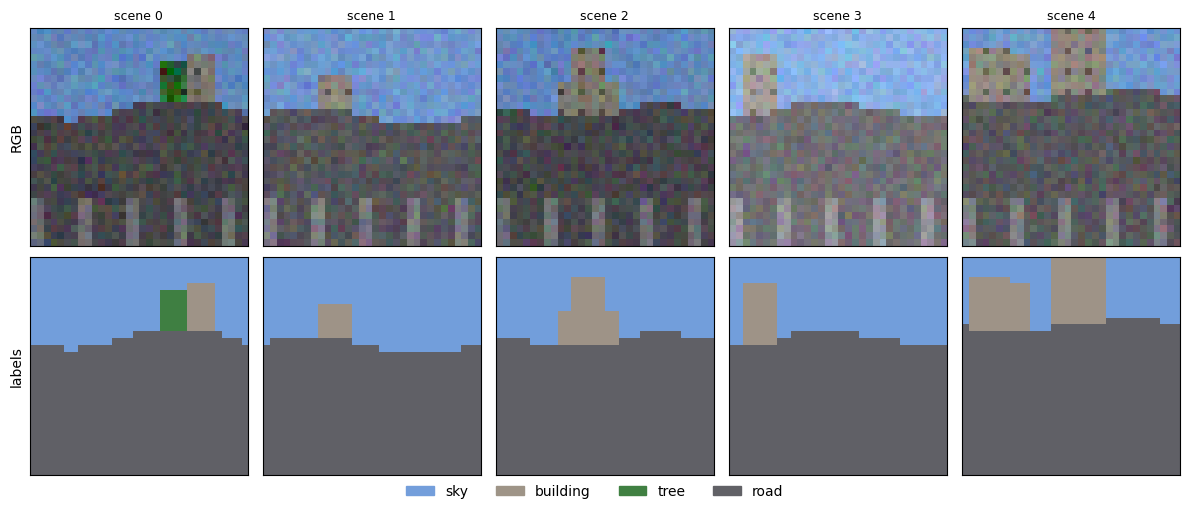

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for k in range(5):
    axes[0, k].imshow(rgb[k].permute(1, 2, 0).cpu().numpy().astype("uint8"))
    axes[0, k].set_title(f"scene {k}", fontsize=9)
    axes[1, k].imshow(PALETTE[lab[k].cpu().numpy()])
    for ax in (axes[0, k], axes[1, k]):
        ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel("RGB", fontsize=10)
axes[1, 0].set_ylabel("labels", fontsize=10)
handles = [plt.Rectangle((0, 0), 1, 1, color=PALETTE[i]) for i in range(4)]
fig.legend(handles, CLASSES, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.03))
plt.tight_layout(); plt.show()

## 4. A single-scale dense TM

Matching the paper's block hyper-parameters as closely as the scale allows: 3×3 patches,
clauses in the low hundreds, and a vote margin `T` of the same order as the paper's 50.

In [6]:
t0 = time.time()
tt.seed_everything(SEED)
single = DenseTsetlinSegmenter(n_planes=x.shape[1], n_classes=4, patch=3,
                               n_clauses=300, T=60, s=10.0).to(device)
single.fit(x_train, l_train, epochs=20)
pred_single = single(x_test)
m_single = segmentation_metrics(pred_single, l_test)
print(f"trained in {time.time() - t0:.0f}s on "
      f"{x_train.shape[0] * H * W:,} patch examples\n")
print(pd.Series(m_single).round(4).to_string())

trained in 17s on 225,280 patch examples

pixel acc       0.9220
mIoU            0.7803
IoU sky         0.9986
IoU building    0.4145
IoU tree        0.8315
IoU road        0.8765


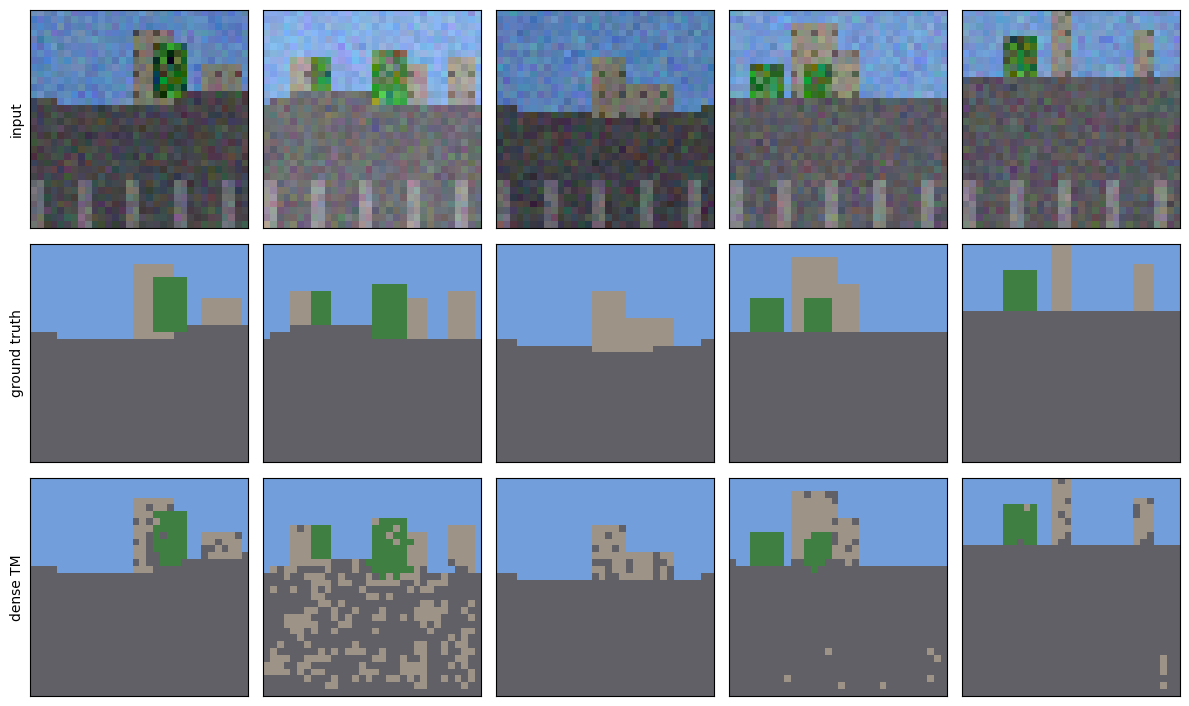

In [7]:
fig, axes = plt.subplots(3, 5, figsize=(12, 7.2))
for k in range(5):
    axes[0, k].imshow(rgb[220 + k].permute(1, 2, 0).cpu().numpy().astype("uint8"))
    axes[1, k].imshow(PALETTE[l_test[k].cpu().numpy()])
    axes[2, k].imshow(PALETTE[pred_single[k].cpu().numpy()])
    for r in range(3):
        axes[r, k].set_xticks([]); axes[r, k].set_yticks([])
for r, name in enumerate(["input", "ground truth", "dense TM"]):
    axes[r, 0].set_ylabel(name, fontsize=10)
plt.tight_layout(); plt.show()

Sky and road are essentially solved; **buildings are where it falls apart**. That is not a
tuning problem. A 3×3 patch of a building interior and a 3×3 patch of road are locally very
similar once illumination jitter is applied — telling them apart needs to know where the
horizon is, which is information that does not exist inside a 3×3 window. This is precisely
the gap an encoder–decoder is supposed to close, and section 7 tests whether it does.

## 5. The sky-vs-rest experiment, read carefully

The paper's Section III-D merges the 32 CamVid classes into **Sky vs. Background** and reports
96.35% ± 1.99 accuracy and 86.43% ± 2.17 IoU (Table I). Those are the numbers in the abstract
and conclusion. Two things need stating before they can be interpreted:

* **They are not a 32-class result.** No 32-class mIoU appears anywhere in the paper, although
  the conclusion describes the 86.43% figure as "mIoU".
* **Table I's own comparison column shows plain U-Net at 99.99%** accuracy *and* 99.99% IoU on
  the same binary task.

What the paper does not report is how hard the binary task is to begin with. Sky is a large,
contiguous region that occupies the top of every frame, so two baselines that contain no
learning at all set the bar:

In [8]:
sky_true = l_test == SKY
row_prior = ((l_train == SKY).float().mean(dim=(0, 2)) > 0.5)   # per-row sky rate from train
row_pred = row_prior.view(1, H, 1).expand_as(sky_true)


def binary_scores(pred_mask, true_mask):
    inter = (pred_mask & true_mask).sum().item()
    union = (pred_mask | true_mask).sum().item()
    return {"accuracy": (pred_mask == true_mask).float().mean().item(),
            "IoU": inter / union if union else 0.0}


rows = {
    "everything is background": binary_scores(torch.zeros_like(sky_true), sky_true),
    "row position only (no image)": binary_scores(row_pred, sky_true),
    "dense TM (this notebook)": binary_scores(pred_single == SKY, sky_true),
}
print(pd.DataFrame(rows).T.round(4).to_string())
print(f"\nsky is {sky_true.float().mean():.1%} of all pixels")

                              accuracy     IoU
everything is background        0.6890  0.0000
row position only (no image)    0.8954  0.7244
dense TM (this notebook)        0.9996  0.9986

sky is 31.1% of all pixels


A classifier that has never seen a pixel — it only knows which *row* a pixel is in — already
reaches a high accuracy and a substantial IoU. That does not invalidate the paper's result,
but it does mean the binary numbers cannot be compared against multi-class segmentation
benchmarks, and a paper reporting them ought to report this floor alongside. The honest
summary of CTM-UNet's evaluation is: *the architecture trains and converges on a dense task* —
which is the contribution the title claims — *and the accuracy evidence is a binary task on
which the baseline it is compared against scores 99.99%.*

## 6. The `Conv2D` front-end that never learns

The paper's CTM block is `Conv2D → binarise → CTM2D → float`, trained with Adam
(`lr = 1.5e-3`, weight decay `1e-4`) on a Dice + Focal loss. But Section II-E states plainly:

> *"this framework is introduced to monitor the training losses instead of involved in the
> training process"*

and Section I-A gives the reason: *"the Tsetlin machine (TM/CTM) is not differentiable. This
hinders the information passes from a PyTorch […] conv layer with backpropagation."*

Taken together, no gradient reaches a `Conv2D` that sits *behind* a CTM block. Whatever those
convolutions are at initialisation is roughly what they remain. So the interesting question is
not whether the block works, but whether a **frozen random projection** in front of the CTM
helps or hurts compared to feeding the booleanized image straight in.

In [9]:
t0 = time.time()
torch.manual_seed(SEED)
frozen_conv = nn.Conv2d(x.shape[1], 24, kernel_size=3, padding=1).to(device)
for p in frozen_conv.parameters():
    p.requires_grad_(False)

with torch.no_grad():                       # Conv2D -> binarise, exactly as in the CTM block
    c_train = (frozen_conv(x_train) > 0).float()
    c_test = (frozen_conv(x_test) > 0).float()

tt.seed_everything(SEED)
conv_front = DenseTsetlinSegmenter(n_planes=c_train.shape[1], n_classes=4, patch=3,
                                   n_clauses=300, T=60, s=10.0).to(device)
conv_front.fit(c_train, l_train, epochs=20)
m_conv = segmentation_metrics(conv_front(c_test), l_test)
print(f"({time.time() - t0:.0f}s)\n")
print(pd.DataFrame({"booleanized image -> CTM": m_single,
                    "frozen Conv2D -> CTM": m_conv}).round(4).to_string())

(17s)

              booleanized image -> CTM  frozen Conv2D -> CTM
pixel acc                       0.9220                0.8667
mIoU                            0.7803                0.6439
IoU sky                         0.9986                0.9269
IoU building                    0.4145                0.2337
IoU tree                        0.8315                0.6132
IoU road                        0.8765                0.8018


The untrained convolution **costs** accuracy and mIoU — building IoU roughly halves. That is
the expected behaviour of a random projection: it mixes the bit planes, and the thresholding
that follows discards the ordering that the thermometer encoding was carefully built to
preserve. A CTM's clauses can only refer to the bits they are handed, so information destroyed
before the block cannot be recovered inside it.

This is worth flagging because the `Conv2D` layers are the component that makes CTM-UNet look
like a hybrid architecture, and by the paper's own account they cannot be trained by the loss
it reports. Any future version of this idea needs either a differentiable relaxation of the CTM
or a TM-native way to produce the intermediate representation.

## 7. Adding context — what U-Net is actually for

Section 4 left buildings unsolved because a 3×3 window cannot see the horizon. U-Net's answer
is to carry information down to a coarse scale and back up through skip connections. Two ways
to get that inside a Tsetlin machine:

**(a) Stagewise vote passing** — the CTM-UNet dataflow. Train a dense TM on a 2×-downsampled
image, upsample its per-pixel votes, booleanize them with a thermometer, and concatenate them
with the fine-resolution patch for a second dense TM. Votes cast to float between blocks is
exactly the paper's `Y = float(V)` step; downsampling Boolean planes with max-pooling is an OR
over the window, which is the TM-native analogue of a pooling layer.

**(b) A patch pyramid** — skip the staging and simply give one dense TM a 3×3 patch at 1×, 2×
and 4× downsampling. Same receptive field, no intermediate machine.

In [10]:
def boolean_downsample(x, factor):
    """OR-pool Boolean planes — the TM-native MaxPool."""
    return F.max_pool2d(x, factor)


def thermometer_votes(v, levels=(-40, -20, -8, 0, 8, 20, 40)):
    """Cast integer votes to Boolean planes without losing their ordering."""
    thr = torch.tensor(levels, dtype=v.dtype, device=v.device).view(1, 1, -1, 1, 1)
    return (v.unsqueeze(2) >= thr).reshape(v.shape[0], -1, v.shape[2], v.shape[3]).float()


# ---- (a) stagewise vote passing -------------------------------------------------------
t0 = time.time()
tt.seed_everything(SEED)
xc_train, xc_test = boolean_downsample(x_train, 2), boolean_downsample(x_test, 2)
coarse = DenseTsetlinSegmenter(n_planes=x.shape[1], n_classes=4, patch=3,
                               n_clauses=300, T=60, s=10.0).to(device)
coarse.fit(xc_train, l_train[:, ::2, ::2], epochs=20)


def with_context(x_fine, x_coarse):
    ctx = thermometer_votes(coarse.votes(x_coarse))
    return torch.cat([x_fine, F.interpolate(ctx, scale_factor=2, mode="nearest")], dim=1)


tt.seed_everything(SEED)
stagewise = DenseTsetlinSegmenter(n_planes=x.shape[1] + 4 * 7, n_classes=4, patch=3,
                                  n_clauses=300, T=60, s=10.0).to(device)
stagewise.fit(with_context(x_train, xc_train), l_train, epochs=20)
m_stage = segmentation_metrics(stagewise(with_context(x_test, xc_test)), l_test)
t_stage = time.time() - t0

# ---- (b) patch pyramid ----------------------------------------------------------------
t0 = time.time()


def pyramid(x, scales=(1, 2, 4), patch=3):
    """3x3 patch at several resolutions, each resampled back to full size."""
    parts = []
    for s in scales:
        xs = x if s == 1 else boolean_downsample(x, s)
        p = patch // 2
        u = F.unfold(F.pad(xs, (p, p, p, p)), kernel_size=patch)
        u = u.transpose(1, 2).reshape(xs.shape[0], xs.shape[2], xs.shape[3], -1).permute(0, 3, 1, 2)
        parts.append(u if s == 1 else F.interpolate(u, size=x.shape[-2:], mode="nearest"))
    return torch.cat(parts, dim=1)


tt.seed_everything(SEED)
px_train, px_test = pyramid(x_train), pyramid(x_test)
pyr = DenseTsetlinSegmenter(n_planes=px_train.shape[1], n_classes=4, patch=1,
                            n_clauses=300, T=60, s=10.0).to(device)
pyr.fit(px_train, l_train, epochs=20)
m_pyr = segmentation_metrics(pyr(px_test), l_test)
t_pyr = time.time() - t0

table = pd.DataFrame({
    "single scale 3x3": m_single,
    "frozen Conv2D -> CTM": m_conv,
    "stagewise votes (CTM-UNet dataflow)": m_stage,
    "patch pyramid 1x/2x/4x": m_pyr,
}).T
print(f"stagewise {t_stage:.0f}s · pyramid {t_pyr:.0f}s\n")
print(table.round(4).to_string())

stagewise 21s · pyramid 17s

                                     pixel acc    mIoU  IoU sky  IoU building  IoU tree  IoU road
single scale 3x3                        0.9220  0.7803   0.9986        0.4145    0.8315    0.8765
frozen Conv2D -> CTM                    0.8667  0.6439   0.9269        0.2337    0.6132    0.8018
stagewise votes (CTM-UNet dataflow)     0.9893  0.9422   0.9952        0.8782    0.9110    0.9847
patch pyramid 1x/2x/4x                  0.9961  0.9679   0.9986        0.9530    0.9242    0.9957


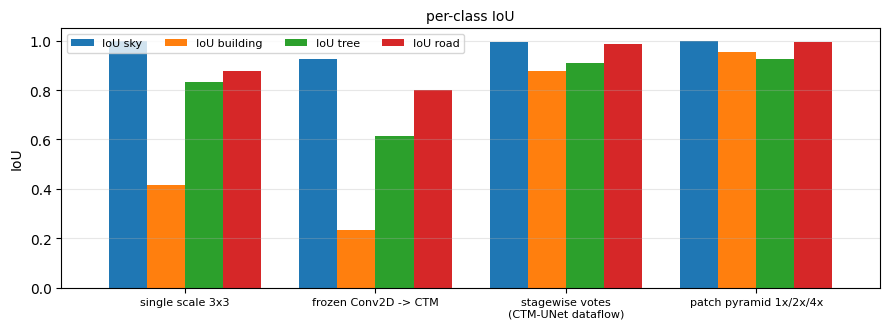

In [11]:
fig, ax = plt.subplots(figsize=(9, 3.4))
table[[f"IoU {c}" for c in CLASSES]].plot.bar(ax=ax, width=0.8)
ax.set_ylabel("IoU"); ax.set_ylim(0, 1.05); ax.grid(axis="y", alpha=0.3)
ax.set_xticklabels([t.get_text().replace(" (", "\n(") for t in ax.get_xticklabels()],
                   rotation=0, fontsize=8)
ax.legend(fontsize=8, ncol=4); ax.set_title("per-class IoU", fontsize=10)
plt.tight_layout(); plt.show()

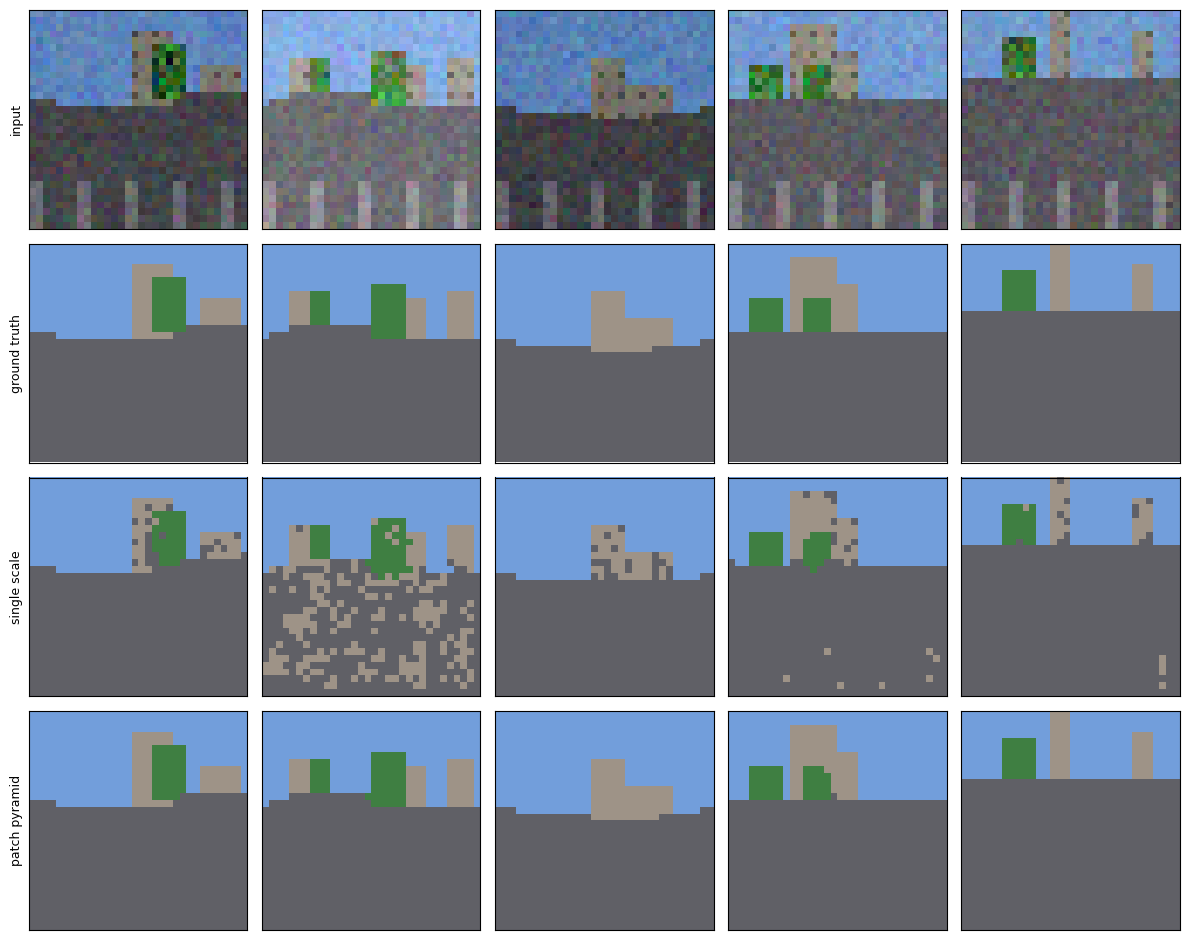

In [12]:
pred_pyr = pyr(px_test)
fig, axes = plt.subplots(4, 5, figsize=(12, 9.5))
for k in range(5):
    axes[0, k].imshow(rgb[220 + k].permute(1, 2, 0).cpu().numpy().astype("uint8"))
    axes[1, k].imshow(PALETTE[l_test[k].cpu().numpy()])
    axes[2, k].imshow(PALETTE[pred_single[k].cpu().numpy()])
    axes[3, k].imshow(PALETTE[pred_pyr[k].cpu().numpy()])
    for r in range(4):
        axes[r, k].set_xticks([]); axes[r, k].set_yticks([])
for r, name in enumerate(["input", "ground truth", "single scale", "patch pyramid"]):
    axes[r, 0].set_ylabel(name, fontsize=9)
plt.tight_layout(); plt.show()

Both context mechanisms recover most of the building class, and the difference between them is
small compared with the difference between having context and not having it. That is the most
useful thing this notebook can say about CTM-UNet's design: **the encoder–decoder is earning
its keep, and the `Conv2D` layers are not.** A TM-native multi-scale scheme — OR-pooled Boolean
planes, thermometer-cast votes — reproduces the benefit without needing a single float
parameter or a gradient anywhere in the model.

## 8. The memory claim

CTM-UNet's second contribution is memory. Tables III and IV report a 31–32× reduction, and the
conclusion reports something else:

> *"CTM-UNet achieves 86.43% mIoU with 52% memory reduction compared to standard UNet"*

Both figures cannot be right, so let's do the arithmetic from the paper's own tables.

In [13]:
mem = pd.DataFrame([
    {"quantity": "feature maps (512x512, batch 1)", "UNet (FP32) MB": 292.35, "CTM-UNet (bool) MB": 9.44},
    {"quantity": "parameters",                      "UNet (FP32) MB": 125.58, "CTM-UNet (bool) MB": 3.924},
])
mem["reduction factor"] = (mem["UNet (FP32) MB"] / mem["CTM-UNet (bool) MB"]).round(1)
mem["memory saved"] = (1 - mem["CTM-UNet (bool) MB"] / mem["UNet (FP32) MB"]).map("{:.1%}".format)
print(mem.to_string(index=False))
print("\nThe tables report ~97% saved (31-32x). The conclusion's '52% memory reduction' does not"
      "\nfollow from either row, and no table in the paper produces it.")

                       quantity  UNet (FP32) MB  CTM-UNet (bool) MB  reduction factor memory saved
feature maps (512x512, batch 1)          292.35               9.440              31.0        96.8%
                     parameters          125.58               3.924              32.0        96.9%

The tables report ~97% saved (31-32x). The conclusion's '52% memory reduction' does not
follow from either row, and no table in the paper produces it.


There is a second, more substantive issue. Tables III and IV are **analytical** — they take the
same 31.4 M parameters and the same feature-map tensors as U-Net and re-price them at 1 bit
instead of 32. But a Tsetlin machine is not a 1-bit convolution: it stores a **Tsetlin automaton
state per literal per clause**, and a clause sees `2 × n_features` literals. The real footprint
is `n_clauses × 2 × n_features × sizeof(state)`, which is what `torchtsetlin` actually
allocates.

In [14]:
def block_bytes(n_clauses, in_planes, patch=3, state_bytes=4):
    """TA-state memory of one CTM block: n_clauses x 2 x (planes*k*k) literals."""
    return n_clauses * 2 * in_planes * patch * patch * state_bytes


rows = []
for name, in_planes, clauses, paper_mb in [("Block 1 (24->64)", 24, 256, 0.007),
                                           ("Block 2 (64->128)", 64, 512, 0.028),
                                           ("Block 3 (128->256)", 128, 1024, 0.111),
                                           ("Block 4 (256->512)", 256, 2048, 0.442)]:
    rows.append({"CTM block": name, "input planes": in_planes, "clauses (~4x channels)": clauses,
                 "paper Table IV, MB": paper_mb,
                 "TA states int32, MB": round(block_bytes(clauses, in_planes) / 2 ** 20, 2),
                 "TA states int8, MB": round(block_bytes(clauses, in_planes, state_bytes=1) / 2 ** 20, 2)})
tab = pd.DataFrame(rows)
tab["understated by"] = (tab["TA states int8, MB"] / tab["paper Table IV, MB"]).round(0).astype(int).astype(str) + "x"
print(tab.to_string(index=False))

states = single.tm.ta_state
print("\nmeasured, this notebook's single-scale head:")
print(f"  training state : ta_state {tuple(states.shape)} x {states.element_size()} B "
      f"= {states.numel() * states.element_size() / 2**20:.3f} MB (state_dtype={single.tm.state_dtype})")
print(f"  with int8 states                                      "
      f"= {states.numel() / 2**20:.3f} MB")
print(f"  inference only : 1-bit include mask                   "
      f"= {states.numel() / 8 / 2**20:.3f} MB"
      f"   <- {states.element_size() * 8}x smaller than the int32 training state")

         CTM block  input planes  clauses (~4x channels)  paper Table IV, MB  TA states int32, MB  TA states int8, MB understated by
  Block 1 (24->64)            24                     256               0.007                 0.42                0.11            16x
 Block 2 (64->128)            64                     512               0.028                 2.25                0.56            20x
Block 3 (128->256)           128                    1024               0.111                 9.00                2.25            20x
Block 4 (256->512)           256                    2048               0.442                36.00                9.00            20x

measured, this notebook's single-scale head:
  training state : ta_state (1200, 216) x 4 B = 0.989 MB (state_dtype=torch.int32)
  with int8 states                                      = 0.247 MB
  inference only : 1-bit include mask                   = 0.031 MB   <- 32x smaller than the int32 training state


Even at one byte per automaton, a CTM block's state costs roughly 15–20× more than the
paper's per-block figure — because that figure prices the convolution the block
*replaces* (its `Parameters` column is U-Net's own parameter count, re-quoted at 1 bit), not
the machine that replaces it. A TM's memory advantage is real: `state_dtype=torch.int8` cuts
training state 4×, and *inference* needs only the 1-bit include mask rather than the counters.
But it is an advantage that has to be measured on the automata, and Tables III and IV do not
measure it.

> `torchtsetlin` note: `ta_state` is the trainable state, while `include` / `include_count` are
> non-persistent caches derived from it. At *inference* time only the include mask matters,
> which is the 1-bit-per-literal figure; training needs the full counters.

## 9. Where this leaves TM segmentation

Putting the pieces together — the paper is the first to show that a TM can be trained inside a
dense-prediction architecture and converge, and that is a real result. What is not yet
established, by this paper or any other:

* **No multi-class segmentation number exists.** The only reported accuracy is binary
  sky-vs-rest, on which the baseline scores 99.99%. There is no published TM Dice or mIoU on
  any multi-class benchmark, so anyone working on this compares against CNN baselines they run
  themselves.
* **The hybrid is not actually hybrid.** No gradient crosses a CTM block, so the float layers
  between blocks are either frozen random projections or trained on a signal the paper states
  is not involved in training. Section 6 suggests they cost accuracy rather than adding any.
* **The architectural question is open, not incremental.** A TM emits a decision from a set of
  matched clauses; segmentation needs a label per pixel. TM blocks in an encoder–decoder,
  sliding-window per-pixel TM classification (section 2), patch-wise TM plus upsampling, and
  convolutional-regression heads (see
  [`04_convolutional_regression_tsetlin.ipynb`](04_convolutional_regression_tsetlin.ipynb))
  are all essentially unexplored.
* **Nothing here is medical.** CTM-UNet is generic urban scene parsing; there is no TM
  segmentation work on MRI or cardiac imaging at all.

## Takeaways

1. **A stock `ConvTsetlinMachine` cannot segment** — clause outputs are OR-ed over patch
   positions, so a 32×32 image yields 4 numbers. Dense prediction means dropping that
   disjunction and evaluating per position.
2. **A dense TM head is short**: unfold to one patch per pixel, run a flat multi-class
   `TsetlinMachine`, fold back. Its one-vs-rest clause banks *are* the paper's K parallel CTM
   heads.
3. **Read the paper's headline number as binary sky-vs-rest**, not a 32-class mIoU, and against
   the trivial baselines in section 5.
4. **The `Conv2D` front-end receives no gradient** and measurably hurts — the paper's own
   statements imply the first, and section 6 measures the second.
5. **Multi-scale context is what moves the hard class**, building IoU roughly doubling, and it
   can be had entirely TM-natively with OR-pooling and thermometer-cast votes.
6. **The memory tables are analytical, not measured**, over-state the advantage by pricing
   convolution weights rather than TA states, and do not support the conclusion's "52%".